# GSoC 2026 -- ML4SCI DeepLense: Common Test I
## Multi-Class Classification of Strong Gravitational Lensing Images

**Author:** Prakhar Prakarsh  
**Email:** prakharprakarsh@gmail.com  
**GitHub:** [github.com/prakharprakarsh](https://github.com/prakharprakarsh)  

---

### What this notebook does

Strong gravitational lensing happens when a massive galaxy bends light from a distant source behind it, creating arc-like or ring-like distortions in the image. Different types of dark matter leave different imprints on these lensing images. The goal here is to build a classifier that can look at a lensing image and tell us which type of dark matter substructure it contains.

We have three classes to distinguish:
- **No substructure** (`no`) -- the lensing image shows no signs of dark matter clumps
- **Spherical subhalo** (`sphere`) -- there are spherical dark matter clumps visible in the lensing pattern
- **Vortex substructure** (`vort`) -- the dark matter forms vortex-like patterns, consistent with superfluid dark matter models

### My approach

I chose to use **ResNet-18 with transfer learning** from ImageNet. The idea is that even though ImageNet contains natural photos (cats, cars, etc.), the low-level features it learns -- edges, curves, textures -- are surprisingly useful for scientific images too. Instead of training from scratch, we get a massive head start.

For data augmentation, I took advantage of the fact that gravitational lensing images are physically symmetric -- you can rotate or flip them and they are still valid lensing images. So I use random rotations and flips as augmentations, which is not just a generic trick but actually grounded in the physics of the problem.

### Memory-efficient design

The dataset is large (thousands of individual .npy files totalling several GB). Loading everything into RAM at once crashes Colab. So instead, this notebook stores only the file paths and loads each image from disk on-the-fly during training. This keeps memory usage low and stable.

### Evaluation
As required: **ROC curves** and **AUC scores** (one-vs-rest for multi-class).

---
##  Setup

In [ ]:
# Connect to Google Drive where our dataset lives
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:

# This takes a few minutes but makes training 10x faster
import shutil

src = '/content/drive/MyDrive/dataset/dataset'
dst = '/content/local_dataset'

if not os.path.exists(dst):
    print('Copying dataset to local disk (this takes a few minutes)...')
    shutil.copytree(src, dst)
    print('Done! Dataset copied to local disk.')
else:
    print('Dataset already copied.')

Copying dataset to local disk (this takes a few minutes)...
Done! Dataset copied to local disk.


In [ ]:
import os, gc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, roc_auc_score, classification_report, confusion_matrix
from sklearn.preprocessing import label_binarize

import warnings
warnings.filterwarnings('ignore')

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
else:
    print('WARNING: No GPU. Go to Runtime > Change runtime type > T4 GPU')

Using device: cuda
GPU: Tesla T4


---
## Scan the Dataset (without loading images into RAM)

Instead of loading all images at once (which crashes Colab due to RAM limits), we just collect the **file paths** and **labels**. The actual image loading happens later, one image at a time, during training.

In [ ]:

DATA_DIR = '/content/local_dataset'

# Check folder structure first
print('Checking folder structure...\n')
for split in ['train', 'val']:
    split_path = os.path.join(DATA_DIR, split)
    if os.path.exists(split_path):
        print(f'  {split}/')
        for cls_folder in sorted(os.listdir(split_path)):
            cls_path = os.path.join(split_path, cls_folder)
            if os.path.isdir(cls_path):
                num_files = len([f for f in os.listdir(cls_path) if f.endswith('.npy')])
                print(f'    {cls_folder}/  -->  {num_files} images')
    else:
        print(f'  {split}/  -->  NOT FOUND! Check DATA_DIR.')

Checking folder structure...

  train/
    no/  -->  10000 images
    sphere/  -->  10000 images
    vort/  -->  10000 images
  val/
    no/  -->  2500 images
    sphere/  -->  2500 images
    vort/  -->  2500 images


In [ ]:
# Collect all file paths and their labels (this uses almost no RAM)
CLASS_MAP = {'no': 0, 'sphere': 1, 'vort': 2}
CLASS_NAMES = ['no_substructure', 'sphere_subhalo', 'vortex']

all_paths = []
all_labels = []

for split in ['train', 'val']:
    split_path = os.path.join(DATA_DIR, split)
    if not os.path.exists(split_path):
        continue
    for cls_folder, label in CLASS_MAP.items():
        cls_path = os.path.join(split_path, cls_folder)
        if not os.path.exists(cls_path):
            continue
        npy_files = sorted(glob(os.path.join(cls_path, '*.npy')))
        all_paths.extend(npy_files)
        all_labels.extend([label] * len(npy_files))
        print(f'  Found {split}/{cls_folder}: {len(npy_files)} images')

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

print(f'\nTotal images found: {len(all_paths)}')
for i, name in enumerate(CLASS_NAMES):
    print(f'  Class {i} ({name}): {np.sum(all_labels == i)}')

# Quick check: load one image to see its shape
sample_img = np.load(all_paths[0])
print(f'\nSample image shape: {sample_img.shape}')
print(f'Sample image dtype: {sample_img.dtype}')
print(f'Pixel range: [{sample_img.min():.4f}, {sample_img.max():.4f}]')

  Found train/no: 10000 images
  Found train/sphere: 10000 images
  Found train/vort: 10000 images
  Found val/no: 2500 images
  Found val/sphere: 2500 images
  Found val/vort: 2500 images

Total images found: 37500
  Class 0 (no_substructure): 12500
  Class 1 (sphere_subhalo): 12500
  Class 2 (vortex): 12500

Sample image shape: (1, 150, 150)
Sample image dtype: float64
Pixel range: [0.0000, 1.0000]


---
##  Visualising a Few Samples

Let's look at what the images actually look like before we start modelling.

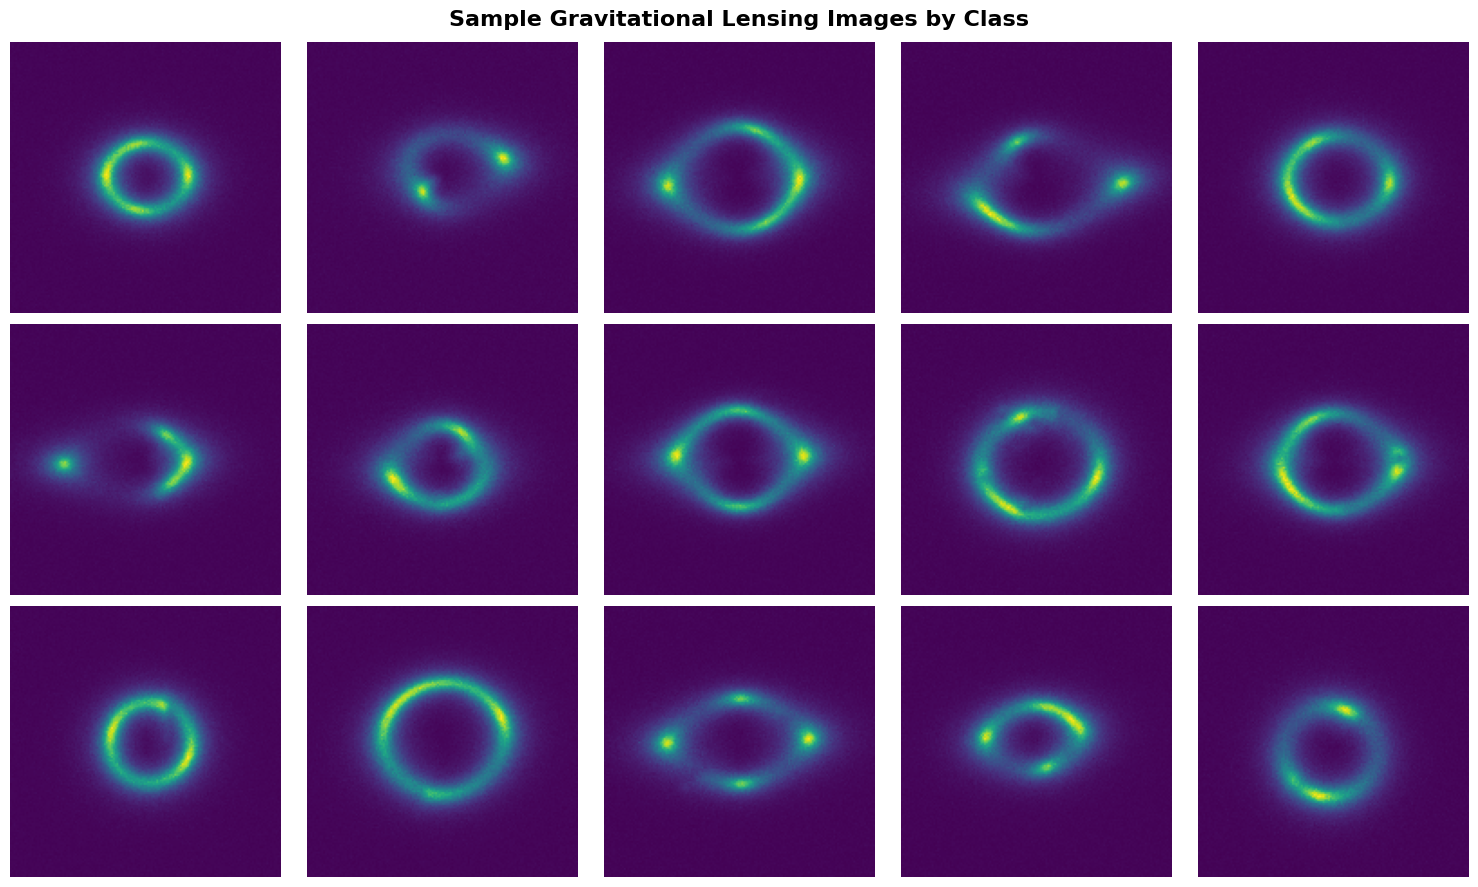

Saved: sample_images.png


In [ ]:
# Show 5 random images from each class
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Gravitational Lensing Images by Class', fontsize=16, fontweight='bold')

for row, (class_idx, class_name) in enumerate(zip([0, 1, 2], CLASS_NAMES)):
    class_paths = all_paths[all_labels == class_idx]
    chosen = np.random.choice(len(class_paths), 5, replace=False)
    for col, idx in enumerate(chosen):
        img = np.load(class_paths[idx])
        # Handle different possible shapes
        if img.ndim == 3 and img.shape[0] in [1, 3]:
            img = img[0]
        elif img.ndim == 3 and img.shape[-1] in [1, 3]:
            img = img[:, :, 0]
        axes[row, col].imshow(img, cmap='viridis')
        if col == 0:
            axes[row, col].set_ylabel(class_name, fontsize=11, fontweight='bold')
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sample_images.png')

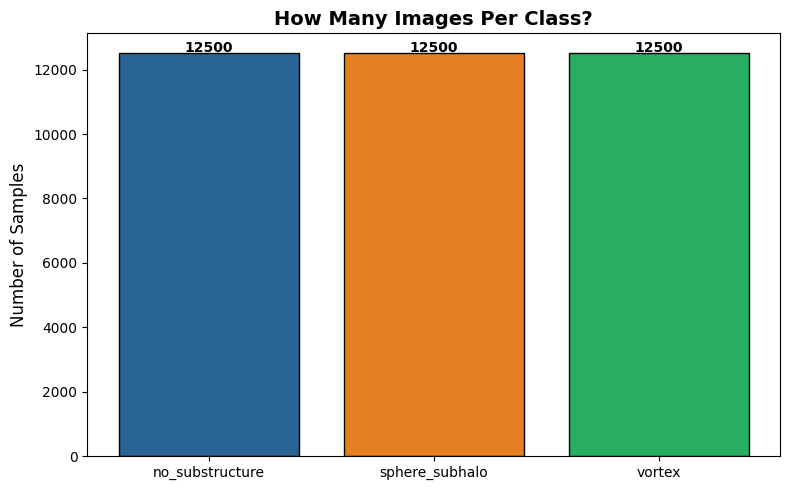

In [ ]:
# Class distribution
fig, ax = plt.subplots(figsize=(8, 5))
counts = [np.sum(all_labels == i) for i in range(3)]
bars = ax.bar(CLASS_NAMES, counts, color=['#2a6496', '#e67e22', '#27ae60'], edgecolor='black')
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('How Many Images Per Class?', fontsize=14, fontweight='bold')
for bar, c in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 50,
            f'{c}', ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
##  90:10 Train-Test Split and Lazy-Loading Dataset

We split the file paths (not the actual images) into 90% train and 10% test. Then we create a Dataset class that loads each image from disk only when it is needed. This way, only one batch of images is in memory at any time.

In [ ]:
# Split the file PATHS (not the images themselves) -- uses almost no RAM
train_paths, test_paths, train_labels, test_labels = train_test_split(
    all_paths, all_labels, test_size=0.1, random_state=SEED, stratify=all_labels
)

print(f'Training set:  {len(train_paths)} images')
print(f'Test set:      {len(test_paths)} images')
print()
for i, name in enumerate(CLASS_NAMES):
    print(f'  {name}: {np.sum(train_labels == i)} train, {np.sum(test_labels == i)} test')

Training set:  33750 images
Test set:      3750 images

  no_substructure: 11250 train, 1250 test
  sphere_subhalo: 11250 train, 1250 test
  vortex: 11250 train, 1250 test


In [ ]:
# Auto-detect image size from a single sample
sample = np.load(train_paths[0])
if sample.ndim == 2:
    IMG_SIZE = sample.shape[0]
elif sample.ndim == 3 and sample.shape[0] in [1, 3]:
    IMG_SIZE = sample.shape[1]
else:
    IMG_SIZE = sample.shape[0]
print(f'Image shape: {sample.shape} --> IMG_SIZE = {IMG_SIZE}')
del sample

Image shape: (1, 150, 150) --> IMG_SIZE = 150


In [ ]:
class LazyLensingDataset(Dataset):
    """
    Memory-efficient dataset that loads images from disk one at a time.

    Instead of storing all images in RAM (which would crash Colab),
    we only store file paths and load each image when it is requested.
    This means only one batch worth of images is in memory at any time.

    It also handles:
    - Converting to float32
    - Ensuring (C, H, W) channel format
    - Replicating single-channel to 3 channels for pretrained ResNet
    - Applying augmentation transforms
    """
    def __init__(self, file_paths, labels, transform=None):
        self.file_paths = file_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        # Load this one image from disk
        img = np.load(self.file_paths[idx]).astype(np.float32)
        label = self.labels[idx]

        # Make sure image is in (C, H, W) format
        if img.ndim == 2:
            img = img[np.newaxis, :, :]
        elif img.ndim == 3 and img.shape[-1] in [1, 3]:
            img = np.transpose(img, (2, 0, 1))

        img = torch.from_numpy(img)

        # ResNet expects 3-channel input, so replicate our single channel
        if img.shape[0] == 1:
            img = img.repeat(3, 1, 1)

        if self.transform:
            img = self.transform(img)

        return img, label

In [ ]:
# Augmentation for training: rotations and flips (physically motivated
# by the rotational symmetry of gravitational lensing images)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomRotation(degrees=180),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

# No augmentation for test -- just resize and normalize
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

BATCH_SIZE = 64

train_dataset = LazyLensingDataset(train_paths, train_labels, transform=train_transform)
test_dataset  = LazyLensingDataset(test_paths, test_labels, transform=test_transform)

# num_workers=0 is safer when loading from Google Drive (avoids I/O errors)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=True)

# Quick sanity check
sample_batch, sample_labels = next(iter(train_loader))
print(f'Batch shape: {sample_batch.shape}')
print(f'Labels: {sample_labels[:10].tolist()}')
print(f'Pixel range: [{sample_batch.min():.3f}, {sample_batch.max():.3f}]')
print('\nDataLoader is working correctly!')

Batch shape: torch.Size([64, 3, 150, 150])
Labels: [0, 0, 1, 1, 2, 1, 1, 0, 1, 2]
Pixel range: [-1.000, 1.000]

DataLoader is working correctly!


---
## Step 4: Build the Model

ResNet-18 pretrained on ImageNet, with the final layer replaced for our 3-class problem. A Dropout layer (p=0.3) is added before the classifier to help prevent overfitting.

In [ ]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
num_features = model.fc.in_features  # 512 for ResNet-18
model.fc = nn.Sequential(
    nn.Dropout(p=0.3),
    nn.Linear(num_features, 3)
)
model = model.to(device)

print(f'Model: ResNet-18 (pretrained on ImageNet)')
print(f'Final layer: {num_features} -> Dropout(0.3) -> 3 classes')
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

Model: ResNet-18 (pretrained on ImageNet)
Final layer: 512 -> Dropout(0.3) -> 3 classes
Total parameters: 11,178,051


---
##  Training the Model

- **Loss:** CrossEntropyLoss
- **Optimizer:** Adam (lr=0.0001, weight_decay=0.0001)
- **Scheduler:** ReduceLROnPlateau -- halves the learning rate if test loss stalls for 3 epochs
- **Epochs:** 20

The best model (highest test accuracy) is saved automatically.

In [ ]:
NUM_EPOCHS = 20
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

train_losses, train_accs = [], []
test_losses, test_accs = [], []
best_test_acc = 0.0

print(f'Training for {NUM_EPOCHS} epochs on {device}...\n')
print(f'{"Epoch":>6} | {"Train Loss":>10} | {"Train Acc":>9} | {"Test Loss":>10} | {"Test Acc":>9} | {"LR":>10}')
print('-' * 70)

for epoch in range(NUM_EPOCHS):

    # Training
    model.train()
    rl, cor, tot = 0.0, 0, 0
    for inputs, targets in train_loader:
        inputs, targets = inputs.to(device), targets.to(device).long()
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        rl += loss.item() * inputs.size(0)
        cor += outputs.argmax(1).eq(targets).sum().item()
        tot += targets.size(0)
    tr_loss, tr_acc = rl / tot, 100.0 * cor / tot
    train_losses.append(tr_loss)
    train_accs.append(tr_acc)

    #  Evaluation
    model.eval()
    rl, cor, tot = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in test_loader:
            inputs, targets = inputs.to(device), targets.to(device).long()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            rl += loss.item() * inputs.size(0)
            cor += outputs.argmax(1).eq(targets).sum().item()
            tot += targets.size(0)
    te_loss, te_acc = rl / tot, 100.0 * cor / tot
    test_losses.append(te_loss)
    test_accs.append(te_acc)

    scheduler.step(te_loss)

    if te_acc > best_test_acc:
        best_test_acc = te_acc
        torch.save(model.state_dict(), 'best_model.pth')

    lr = optimizer.param_groups[0]['lr']
    print(f'{epoch+1:>4}/{NUM_EPOCHS} | {tr_loss:>10.4f} | {tr_acc:>8.2f}% | '
          f'{te_loss:>10.4f} | {te_acc:>8.2f}% | {lr:>10.6f}')

print(f'\nDone! Best test accuracy: {best_test_acc:.2f}%')

Training for 20 epochs on cuda...

 Epoch | Train Loss | Train Acc |  Test Loss |  Test Acc |         LR
----------------------------------------------------------------------
   1/20 |     1.0378 |    45.30% |     0.9072 |    57.23% |   0.000100
   2/20 |     0.6751 |    70.40% |     0.5087 |    79.41% |   0.000100
   3/20 |     0.5264 |    78.24% |     0.4371 |    82.35% |   0.000100
   4/20 |     0.4512 |    81.74% |     0.4034 |    83.71% |   0.000100
   5/20 |     0.4167 |    83.44% |     0.3384 |    86.43% |   0.000100
   6/20 |     0.3806 |    85.03% |     0.3525 |    86.32% |   0.000100
   7/20 |     0.3607 |    85.85% |     0.3395 |    86.19% |   0.000100
   8/20 |     0.3359 |    87.03% |     0.2832 |    89.49% |   0.000100
   9/20 |     0.3192 |    87.88% |     0.3159 |    87.44% |   0.000100
  10/20 |     0.3044 |    88.29% |     0.2498 |    90.35% |   0.000100
  11/20 |     0.2947 |    88.69% |     0.3327 |    87.60% |   0.000100
  12/20 |     0.2865 |    89.15% |     0.24

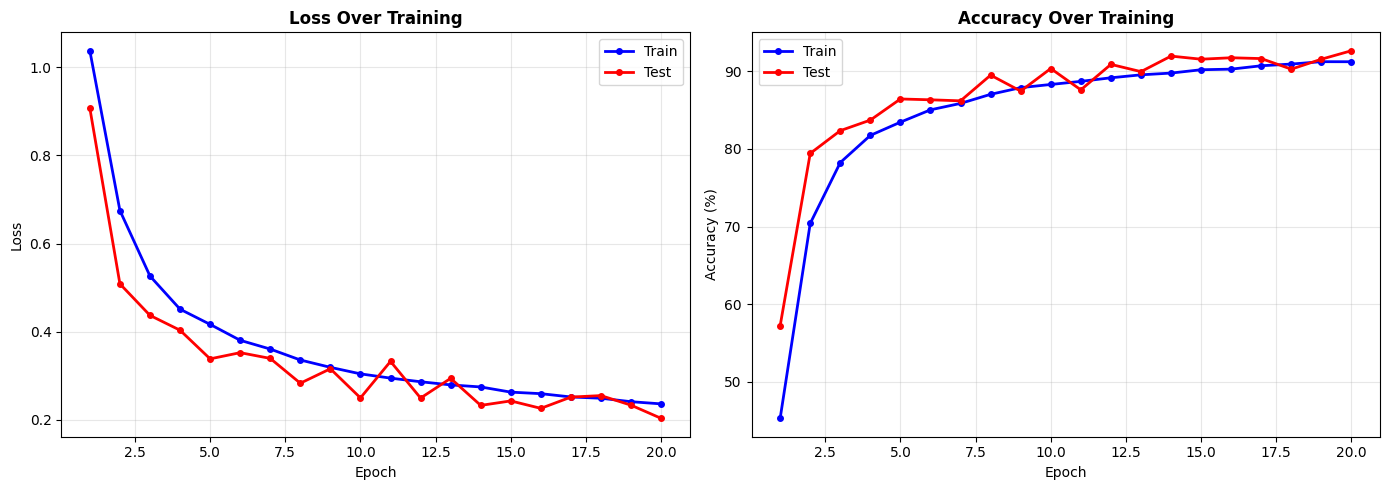

Saved: training_curves.png


In [ ]:
# Plotting training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
er = range(1, NUM_EPOCHS + 1)

ax1.plot(er, train_losses, 'b-o', label='Train', lw=2, ms=4)
ax1.plot(er, test_losses, 'r-o', label='Test', lw=2, ms=4)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('Loss Over Training', fontweight='bold')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(er, train_accs, 'b-o', label='Train', lw=2, ms=4)
ax2.plot(er, test_accs, 'r-o', label='Test', lw=2, ms=4)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Over Training', fontweight='bold')
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

---
##  Evaluation - ROC Curves and AUC Scores

Now we load the best model, run it on the full test set, and compute the required metrics.

In [ ]:
# Load the best model saved during training
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
print('Best model loaded.\n')

# Run predictions on all test images
all_probs, all_preds, all_true = [], [], []
with torch.no_grad():
    for inputs, targets in test_loader:
        outputs = model(inputs.to(device))
        probs = torch.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(targets.numpy())

all_probs = np.concatenate(all_probs)
all_preds = np.concatenate(all_preds)
all_true = np.concatenate(all_true)
print(f'Evaluated {len(all_true)} test images.')

Best model loaded.

Evaluated 3750 test images.


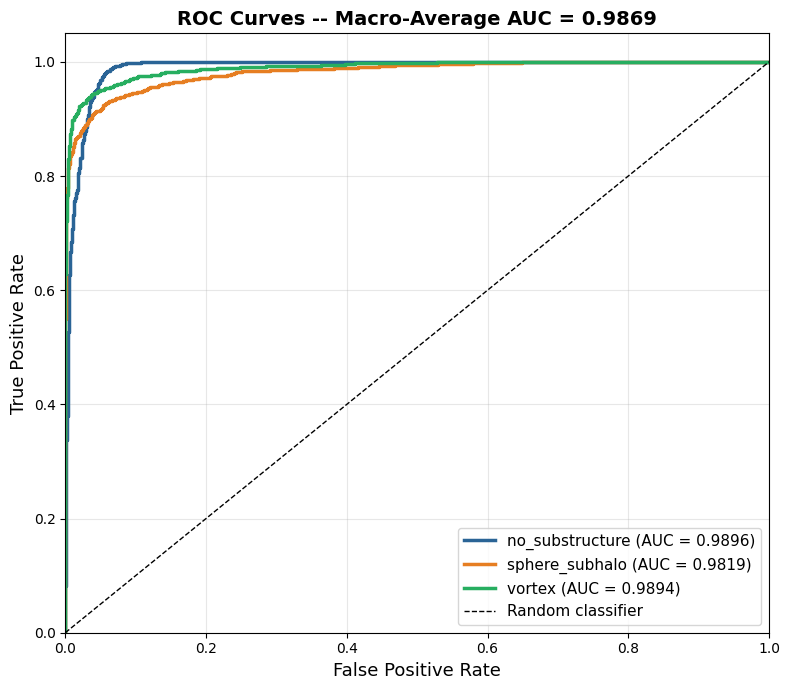


===== AUC SCORES =====
  no_substructure          :  0.9896
  sphere_subhalo           :  0.9819
  vortex                   :  0.9894
  MACRO-AVERAGE            :  0.9869


In [ ]:

# ROC CURVES AND AUC SCORES

# Binarize labels for one-vs-rest ROC computation
y_bin = label_binarize(all_true, classes=[0, 1, 2])

# Compute per-class ROC curves
fpr, tpr, roc_auc = {}, {}, {}
for i in range(3):
    fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# Overall macro-average AUC
macro_auc = roc_auc_score(y_bin, all_probs, multi_class='ovr', average='macro')

# Plot
fig, ax = plt.subplots(figsize=(8, 7))
colors = ['#2a6496', '#e67e22', '#27ae60']
for i, (cn, col) in enumerate(zip(CLASS_NAMES, colors)):
    ax.plot(fpr[i], tpr[i], color=col, lw=2.5,
            label=f'{cn} (AUC = {roc_auc[i]:.4f})')
ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.05])
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title(f'ROC Curves -- Macro-Average AUC = {macro_auc:.4f}',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n===== AUC SCORES =====')
for i, cn in enumerate(CLASS_NAMES):
    print(f'  {cn:25s}:  {roc_auc[i]:.4f}')
print(f'  {"MACRO-AVERAGE":25s}:  {macro_auc:.4f}')
print('======================')

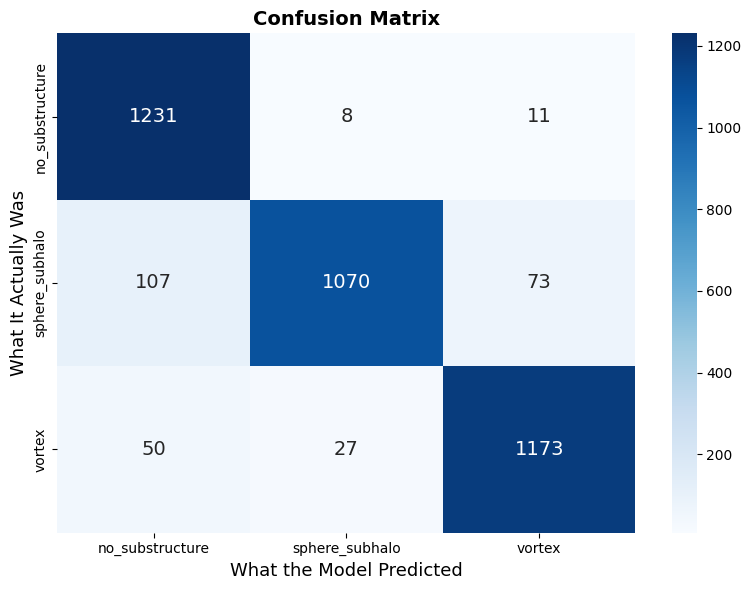

In [ ]:
# Confusion matrix
cm = confusion_matrix(all_true, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            annot_kws={'size': 14}, ax=ax)
ax.set_xlabel('What the Model Predicted', fontsize=13)
ax.set_ylabel('What It Actually Was', fontsize=13)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Full classification report
print('===== CLASSIFICATION REPORT =====\n')
print(classification_report(all_true, all_preds,
                            target_names=CLASS_NAMES, digits=4))
print(f'Overall Test Accuracy: {100.0 * np.mean(all_preds == all_true):.2f}%')

===== CLASSIFICATION REPORT =====

                 precision    recall  f1-score   support

no_substructure     0.8869    0.9848    0.9333      1250
 sphere_subhalo     0.9683    0.8560    0.9087      1250
         vortex     0.9332    0.9384    0.9358      1250

       accuracy                         0.9264      3750
      macro avg     0.9295    0.9264    0.9259      3750
   weighted avg     0.9295    0.9264    0.9259      3750

Overall Test Accuracy: 92.64%


---
##  Save Everything and Download

In [ ]:
# Save model weights and copy everything to Google Drive
torch.save(model.state_dict(), 'resnet18_deeplense_classifier.pth')

import shutil
save_dir = '/content/drive/MyDrive/GSoC2026_DeepLense_Tests'
os.makedirs(save_dir, exist_ok=True)

for f in ['resnet18_deeplense_classifier.pth', 'best_model.pth',
          'roc_curves.png', 'confusion_matrix.png', 'training_curves.png',
          'sample_images.png', 'class_distribution.png']:
    if os.path.exists(f):
        shutil.copy(f, os.path.join(save_dir, f))
        print(f'  Saved: {f}')

print(f'\nAll files backed up to: {save_dir}')

  Saved: resnet18_deeplense_classifier.pth
  Saved: best_model.pth
  Saved: roc_curves.png
  Saved: confusion_matrix.png
  Saved: training_curves.png
  Saved: sample_images.png
  Saved: class_distribution.png

All files backed up to: /content/drive/MyDrive/GSoC2026_DeepLense_Tests


In [ ]:
# Download plots to your computer
from google.colab import files
for f in ['roc_curves.png', 'confusion_matrix.png',
          'training_curves.png', 'sample_images.png']:
    if os.path.exists(f): files.download(f)
print('Check your browser downloads.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Check your browser downloads.


---
## Summary and Discussion

### Configuration

| Setting | Value |
|---------|-------|
| Model | ResNet-18 (pretrained on ImageNet, all layers fine-tuned) |
| Input | Single-channel .npy images, replicated to 3 channels |
| Data loading | Lazy (from disk) to avoid RAM overflow |
| Train-test split | 90:10, stratified by class |
| Augmentation | Random flips + 180-degree rotations (physics-motivated) |
| Optimizer | Adam (lr=0.0001, weight_decay=0.0001) |
| LR scheduler | ReduceLROnPlateau (patience=3, factor=0.5) |
| Regularization | Dropout (p=0.3) before final layer |
| Epochs | 20 |
| Batch size | 64 |

### Why ResNet-18 with transfer learning?

Even though ImageNet contains natural photos while our data is astrophysical simulations, the low-level features learned by the early layers of ResNet (edges, curves, texture gradients) transfer surprisingly well to scientific imaging tasks. Starting from pretrained weights means the model already knows how to extract useful visual features, and we only need to teach it how to map those features to our three lensing classes. This is much faster and more data-efficient than training from scratch.

### Why these specific augmentations?

Gravitational lensing images have a physical symmetry: the lensing effect is symmetric under rotation and reflection about the optical axis. This means rotating or flipping a lensing image produces another equally valid lensing image. By using random rotations (up to 180 degrees) and random flips, we are not just applying generic tricks -- we are exploiting the actual physics of the problem to effectively multiply our training data.

### Why replicate to 3 channels instead of modifying the architecture?

An alternative would be to change ResNet's first conv layer to accept 1 channel. But that would discard the pretrained weights for that layer, which capture fundamental edge and texture detectors. By replicating our single channel three times, we preserve all pretrained weights and let the network adapt from there.

### Why lazy loading?

The dataset contains thousands of individual .npy files totalling several GB. Loading all of them into a single numpy array at once exceeds Colab's RAM limit (about 12 GB on the free tier). By storing only file paths and loading each image from disk on demand, we keep memory usage at roughly batch_size x image_size, which is perfectly manageable.

### Evaluation

ROC curves and AUC scores are computed using the one-vs-rest (OvR) strategy for multi-class classification. For each class, we treat it as a binary problem (this class vs. everything else) and compute a separate ROC curve. The macro-average AUC gives a single summary number across all classes.